# CIS6005 Computational Intelligence
## Notebook 03 — Exploratory Data Analysis (EDA)
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### What is EDA?
Exploratory Data Analysis is the process of visually and statistically exploring data to:
- Discover patterns
- Detect anomalies and outliers
- Understand feature-target relationships
- Inform feature engineering and modelling decisions

> **Rule:** Every chart must be followed by an interpretation. Graphs without explanation are worthless.

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA     = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA    = PROJECT_ROOT / 'data' / 'processed'

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE      = {'fit': '#2ecc71', 'unhealthy': '#e74c3c', 'at-risk': '#f39c12'}

train_df = pd.read_csv(RAW_DATA / 'train.csv')
test_df  = pd.read_csv(RAW_DATA / 'test.csv')

# Identify column types
numerical_cols   = [c for c in train_df.select_dtypes(include=['int64','float64']).columns if c != 'id']
categorical_cols = [c for c in train_df.select_dtypes(include='object').columns if c != 'health_condition']
TARGET           = 'health_condition'

print('✅ Setup complete')
print(f'Numerical : {numerical_cols}')
print(f'Categorical: {categorical_cols}')

✅ Setup complete
Numerical : ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 1. Target Distribution (Revisited)

**Why:** We start EDA by anchoring on our goal — predicting `health_condition`. Every subsequent chart will be interpreted through this lens.

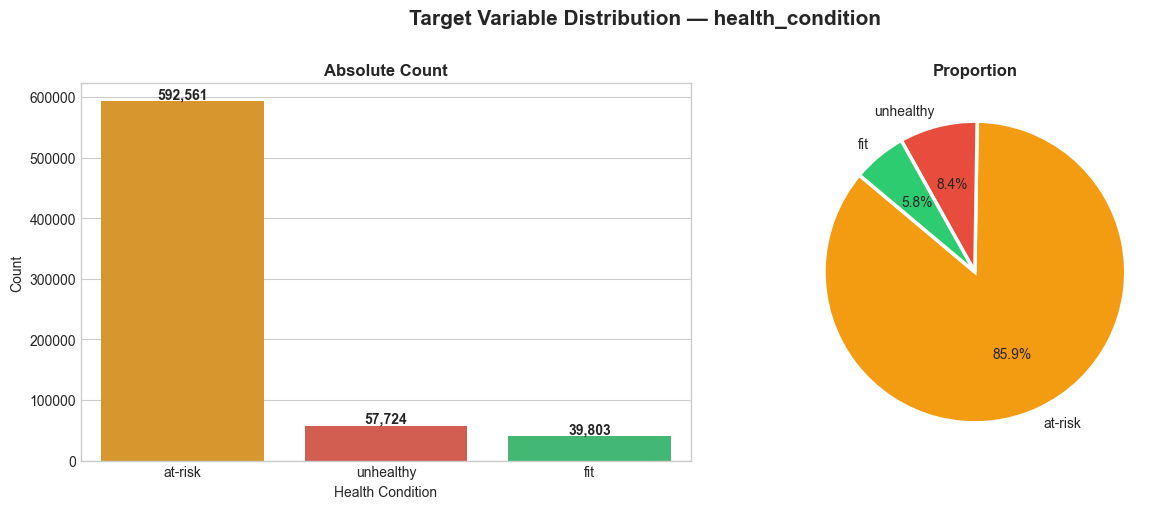


📊 INTERPRETATION:
   Examine the proportions above.
   If any class is significantly smaller, class imbalance exists.
   We handle this in Phase 7 using class_weight="balanced".


In [2]:
# ============================================================
# SECTION 1: Target Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable Distribution — health_condition', fontsize=15, fontweight='bold', y=1.01)

counts = train_df[TARGET].value_counts()
colors = [PALETTE[c] for c in counts.index]

# Countplot
sns.countplot(data=train_df, x=TARGET, palette=PALETTE, order=counts.index, ax=axes[0])
axes[0].set_title('Absolute Count', fontweight='bold')
axes[0].set_xlabel('Health Condition')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2.5})
axes[1].set_title('Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_01_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   Examine the proportions above.')
print('   If any class is significantly smaller, class imbalance exists.')
print('   We handle this in Phase 7 using class_weight="balanced".')

## 2. Numerical Feature Distributions

**Why:** Distributions tell us:
- Is the data normally distributed? (Important for some models)
- Are there skewed distributions? (May need log transform)
- Are there extreme outliers?

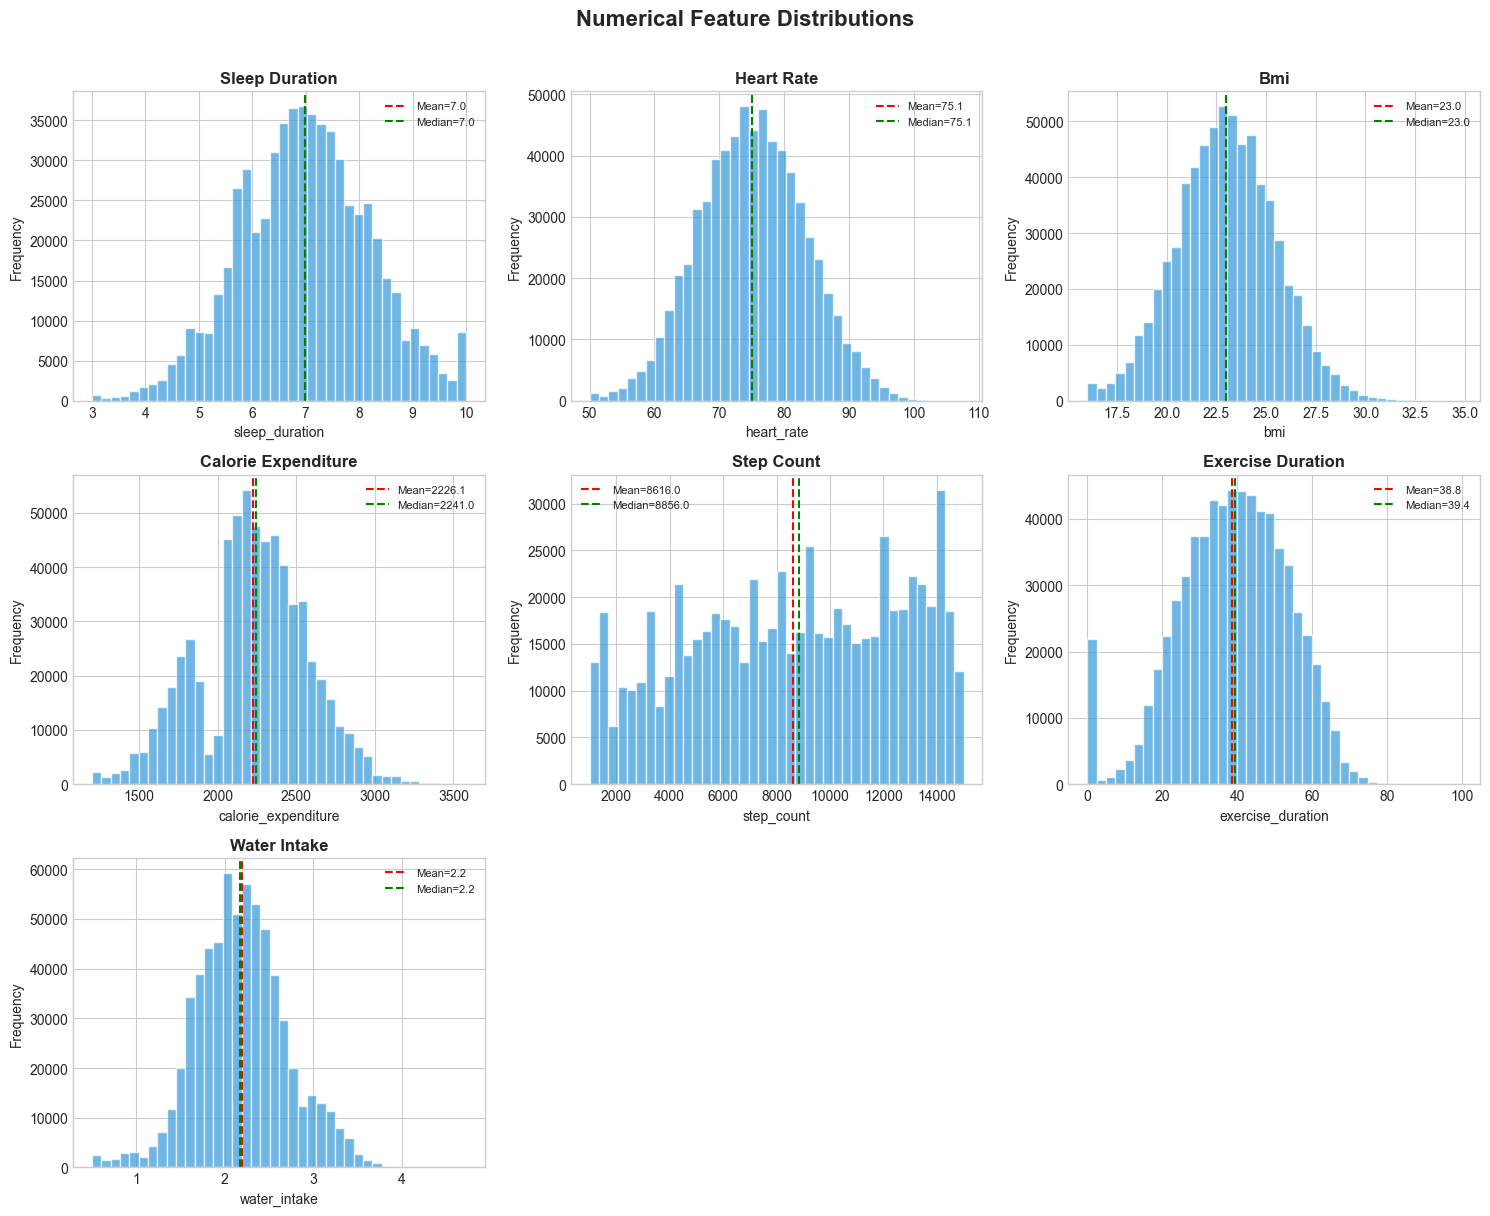


📊 INTERPRETATION:
   - Symmetric bell curves = normally distributed (good for many models)
   - Long right tail = positive skew (may need log transform)
   - Mean far from Median = outlier influence


In [3]:
# ============================================================
# SECTION 2: Numerical Feature Distributions (Histograms)
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[i].hist(train_df[col].dropna(), bins=40, color='#3498db', alpha=0.7, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    mean_val   = train_df[col].mean()
    median_val = train_df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median={median_val:.1f}')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_02_num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   - Symmetric bell curves = normally distributed (good for many models)')
print('   - Long right tail = positive skew (may need log transform)')
print('   - Mean far from Median = outlier influence')

## 3. Feature vs Target (Box Plots)

**Why:** Box plots show how numerical features differ across health condition classes. If a feature separates the boxes cleanly, it is a strong predictor.

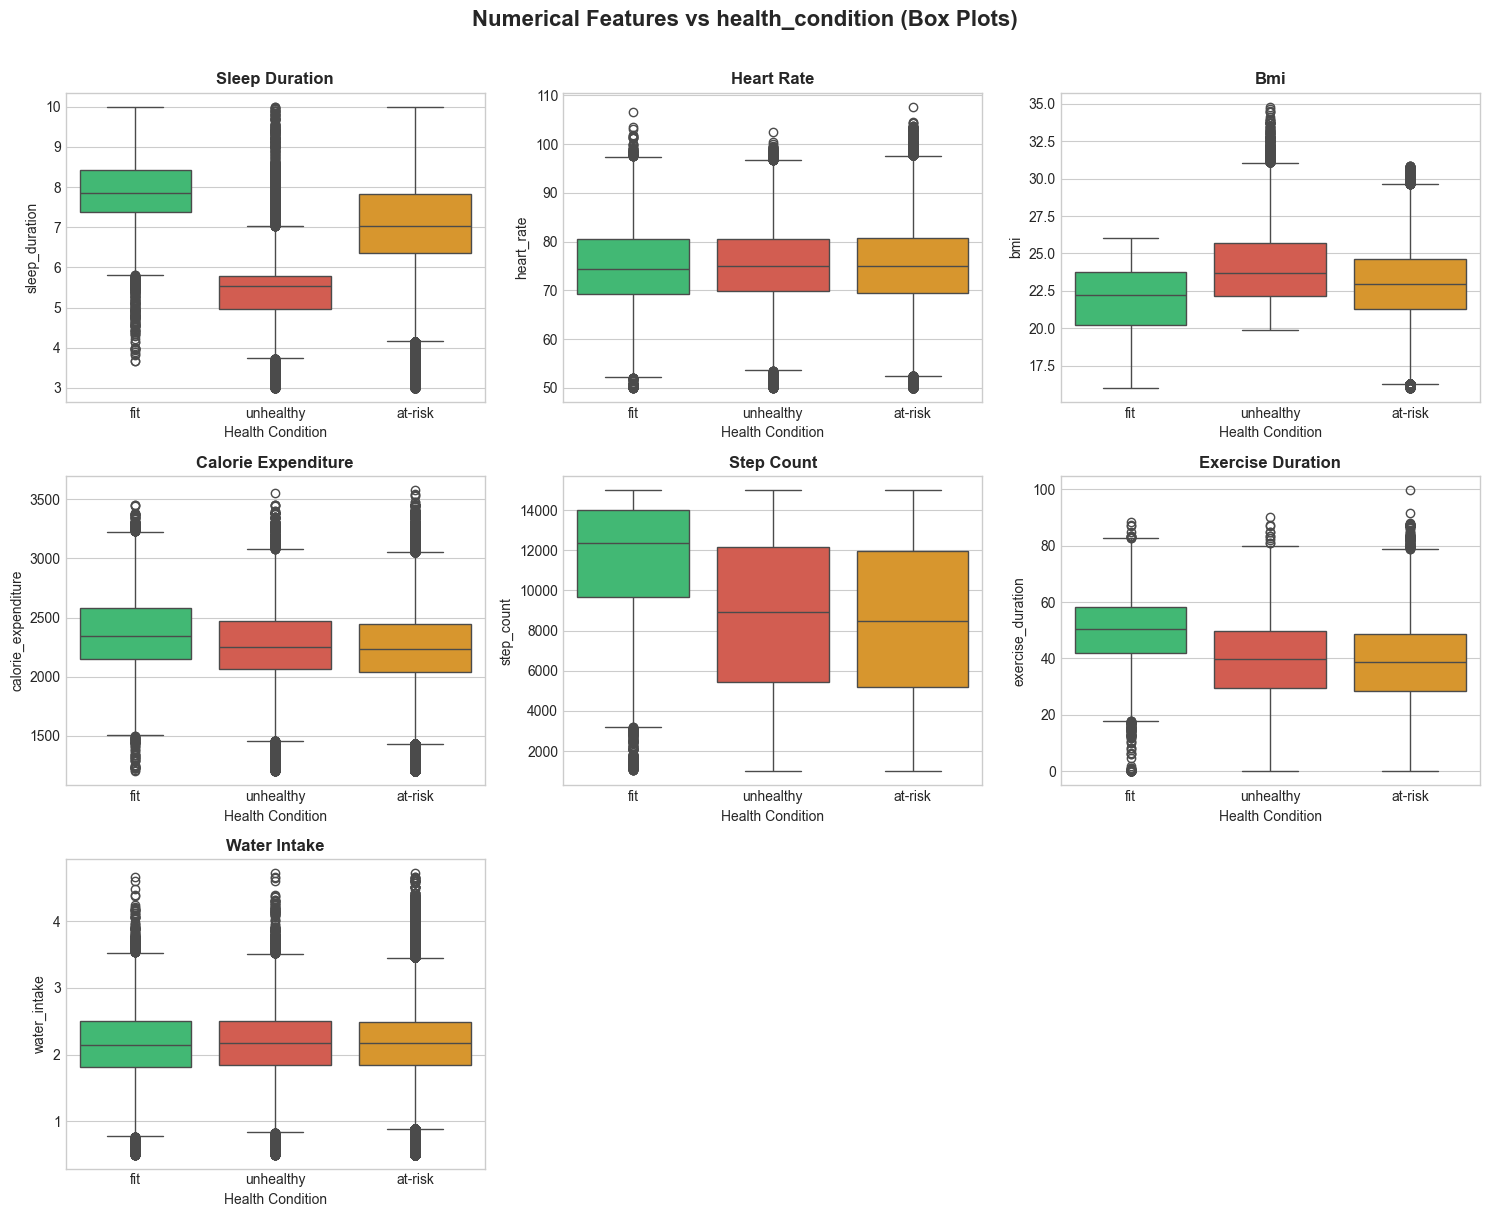


📊 INTERPRETATION:
   - If boxes are at different heights per class → feature is predictive
   - If boxes heavily overlap → feature alone is not discriminative
   - Dots outside whiskers = outliers


In [4]:
# ============================================================
# SECTION 3: Numerical Features vs Target (Box Plots)
# ============================================================

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle('Numerical Features vs health_condition (Box Plots)', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

class_order = ['fit', 'unhealthy', 'at-risk']

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=train_df, x=TARGET, y=col,
        palette=PALETTE, order=class_order, ax=axes[i]
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Health Condition')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   - If boxes are at different heights per class → feature is predictive')
print('   - If boxes heavily overlap → feature alone is not discriminative')
print('   - Dots outside whiskers = outliers')

## 4. Categorical Feature Analysis

**Why:** Categorical features (like gender, diet_type, smoking_alcohol) need to be visualised differently — we use count plots grouped by the target.

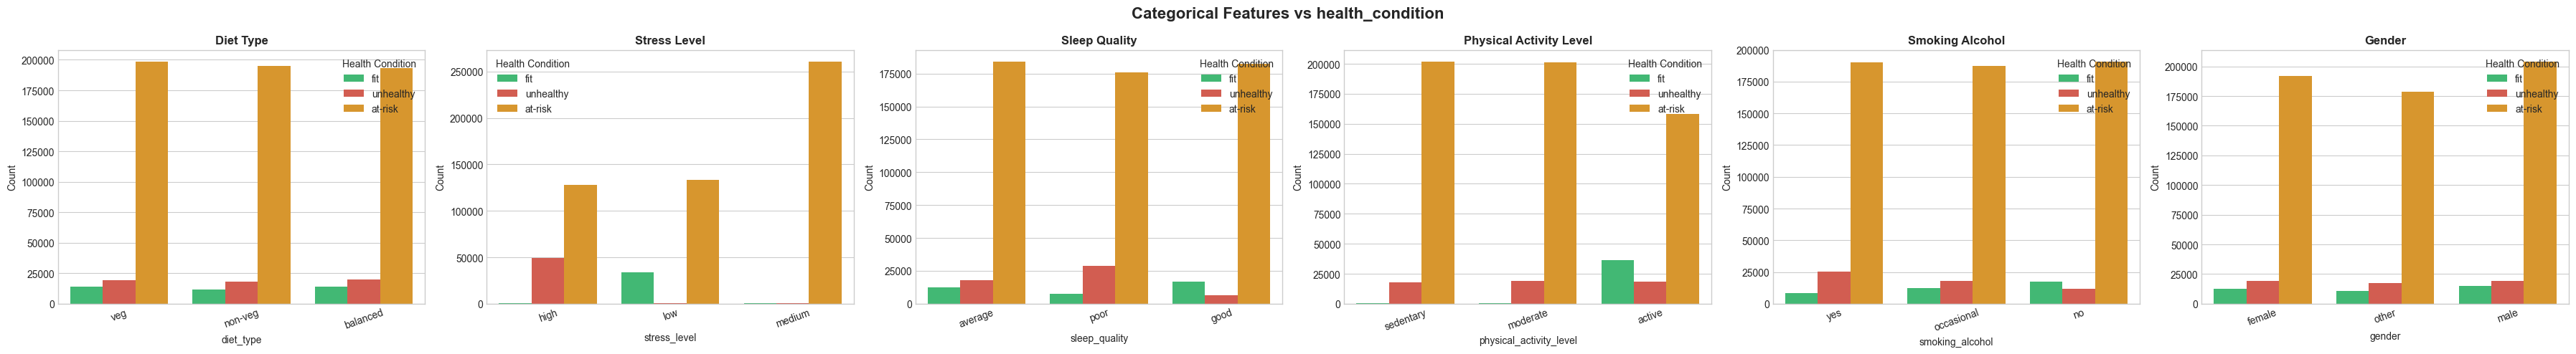


📊 INTERPRETATION:
   - Look for uneven distributions within each category
   - If smoking_alcohol=True has more "at-risk" → it is predictive


In [5]:
# ============================================================
# SECTION 4: Categorical Features vs Target
# ============================================================

if categorical_cols:
    n_cat = len(categorical_cols)
    fig, axes = plt.subplots(1, n_cat, figsize=(6 * n_cat, 5))
    if n_cat == 1:
        axes = [axes]
    fig.suptitle('Categorical Features vs health_condition', fontsize=16, fontweight='bold')

    for i, col in enumerate(categorical_cols):
        sns.countplot(
            data=train_df, x=col,
            hue=TARGET, palette=PALETTE,
            hue_order=class_order, ax=axes[i]
        )
        axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Health Condition')
        axes[i].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.savefig(PROC_DATA / 'eda_04_categorical.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No categorical features found.')

print('\n📊 INTERPRETATION:')
print('   - Look for uneven distributions within each category')
print('   - If smoking_alcohol=True has more "at-risk" → it is predictive')

## 5. Outlier Detection (IQR Method)

**Why:** Outliers are extreme data points that distort model training. The IQR (Interquartile Range) method is the industry standard for identifying them.

**Formula:** Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [6]:
# ============================================================
# SECTION 5: Outlier Detection using IQR Method
# ============================================================

print('=' * 65)
print('  Outlier Detection Report (IQR Method)')
print('=' * 65)
print(f'  {"Column":<30} {"Outliers":>10} {"Percentage":>12}')
print('-' * 65)

outlier_summary = {}
for col in numerical_cols:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    pct = (len(outliers) / len(train_df)) * 100
    outlier_summary[col] = len(outliers)
    
    flag = '⚠️' if pct > 5 else '  '
    print(f'  {flag} {col:<28} {len(outliers):>10,} {pct:>11.2f}%')

print('=' * 65)
print('  ⚠️ = >5% outliers — monitor during model training')

  Outlier Detection Report (IQR Method)
  Column                           Outliers   Percentage
-----------------------------------------------------------------
     sleep_duration                    2,020        0.29%
     heart_rate                        2,825        0.41%
     bmi                               5,352        0.78%
     calorie_expenditure              12,831        1.86%
     step_count                            0        0.00%
     exercise_duration                   104        0.02%
     water_intake                     11,388        1.65%
  ⚠️ = >5% outliers — monitor during model training


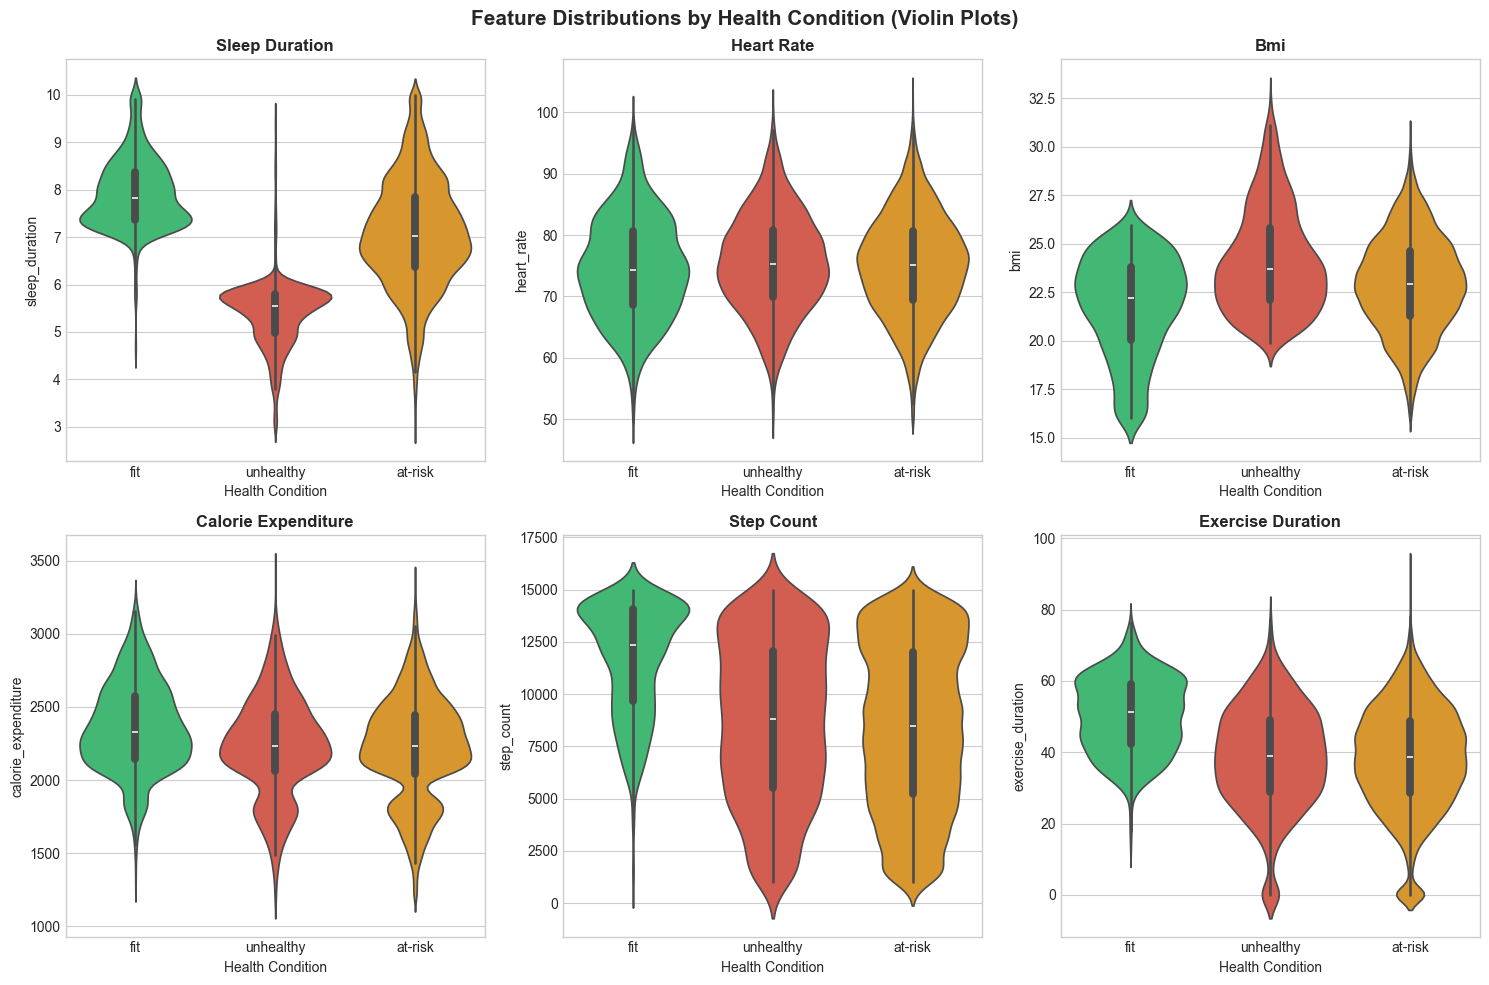

In [7]:
# ============================================================
# SECTION 5b: Visualise Outliers with Violin Plots
# ============================================================

# Select top 6 numerical features for violin plot
vis_cols = numerical_cols[:6] if len(numerical_cols) >= 6 else numerical_cols

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions by Health Condition (Violin Plots)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(vis_cols):
    # Downsample train_df to 20,000 samples for fast plotting
    plot_df = train_df.sample(20000, random_state=42) if len(train_df) > 20000 else train_df
    sns.violinplot(
        data=plot_df, x=TARGET, y=col,
        palette=PALETTE, order=class_order,
        inner='box', ax=axes[i]
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Health Condition')

for j in range(len(vis_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_05_violin.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Correlation Analysis

**Why:** Correlation tells us which features move together. High correlation between two features means they carry similar information — one may be redundant (multicollinearity).

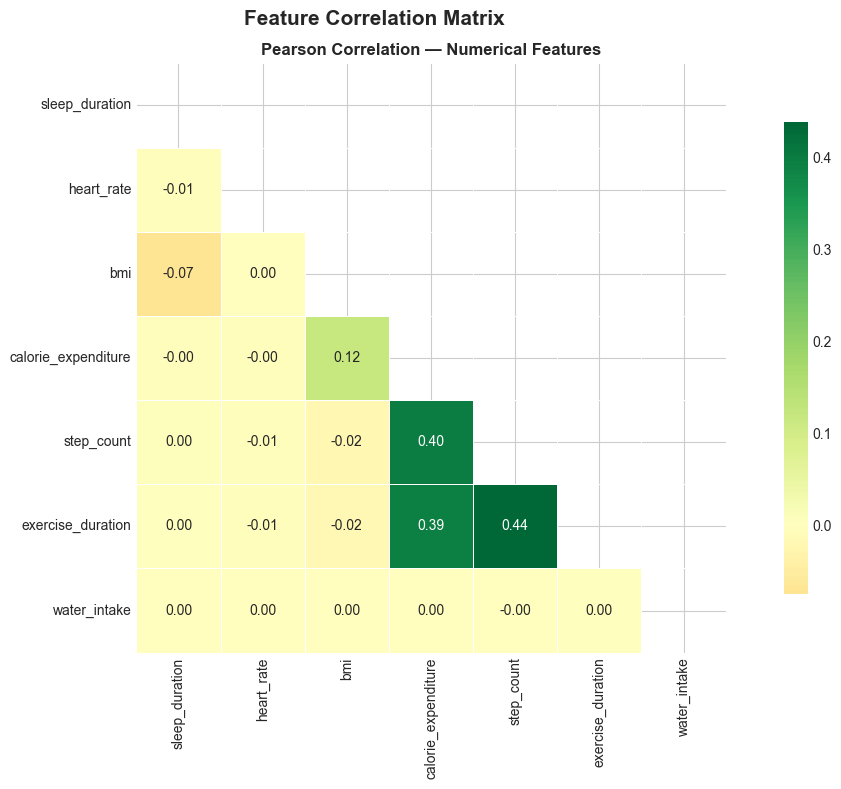


📊 HIGH CORRELATIONS (|r| > 0.7):
   No pairs exceed |0.7|. Low multicollinearity — good!


In [8]:
# ============================================================
# SECTION 6: Correlation Heatmap
# ============================================================

# Select only numerical columns for correlation
corr_df = train_df[numerical_cols].copy()

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Feature Correlation Matrix', fontsize=15, fontweight='bold')

corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Pearson Correlation — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Report high correlations
print('\n📊 HIGH CORRELATIONS (|r| > 0.7):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

if high_corr:
    for a, b, r in high_corr:
        print(f'   {a} ↔ {b}: r = {r}')
else:
    print('   No pairs exceed |0.7|. Low multicollinearity — good!')

## 7. Pairplot — Feature Interactions

**Why:** A pairplot shows scatter plots between every pair of features, coloured by target class — revealing which feature combinations separate the classes best.

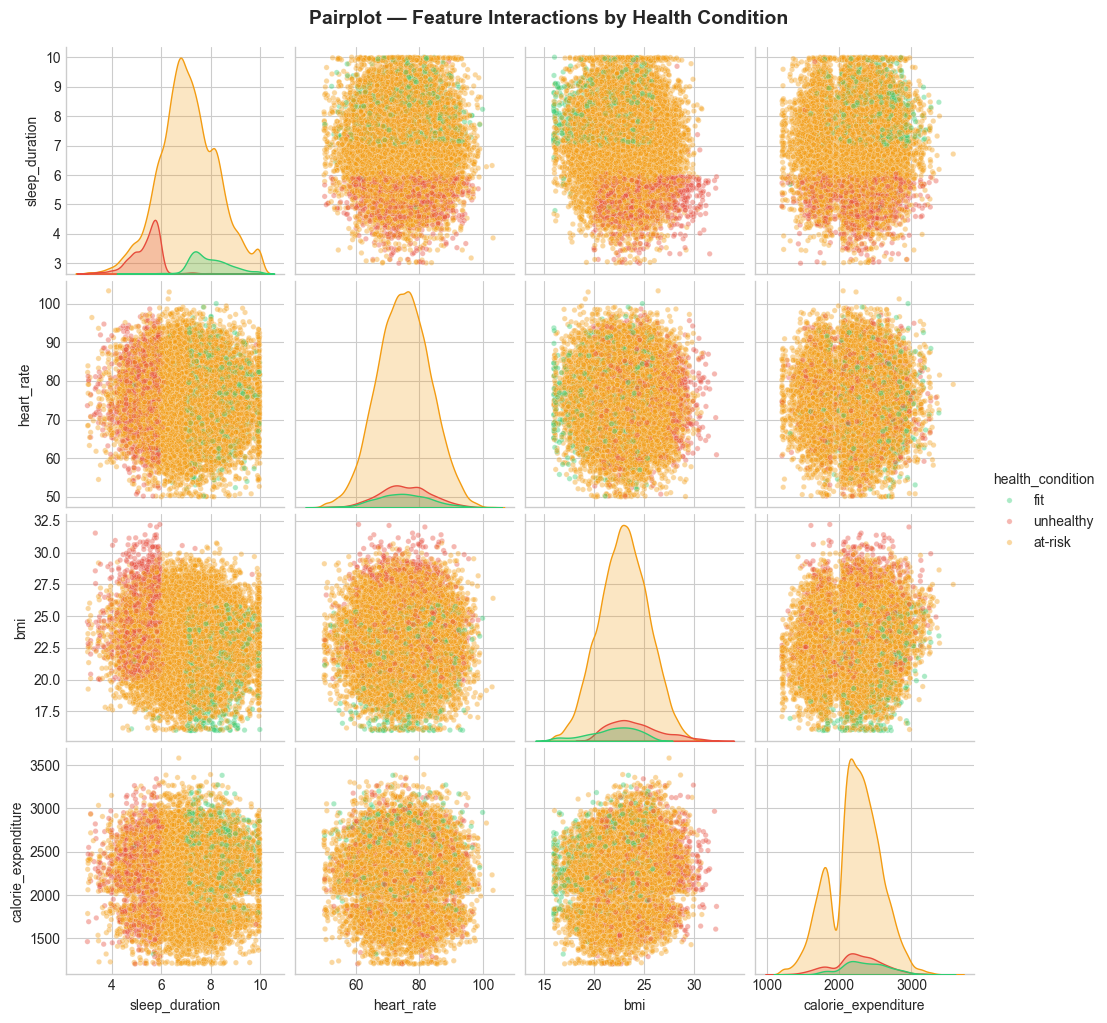


📊 INTERPRETATION:
   - Diagonal: KDE distribution per class per feature
   - Off-diagonal: scatter of feature pairs coloured by class
   - Clear separation between colour clusters = strong feature pair


In [9]:
# ============================================================
# SECTION 7: Pairplot (Top 4 Most Informative Features)
# ============================================================

# Use first 4 numerical features to keep it readable
pair_cols = numerical_cols[:4]
pair_df   = train_df[pair_cols + [TARGET]].dropna()

# Downsample to 20,000 samples for fast pairplot visualization
if len(pair_df) > 20000:
    pair_df = pair_df.sample(20000, random_state=42)

g = sns.pairplot(
    pair_df,
    hue=TARGET,
    palette=PALETTE,
    hue_order=class_order,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
g.figure.suptitle('Pairplot — Feature Interactions by Health Condition',
                   y=1.02, fontsize=14, fontweight='bold')

plt.savefig(PROC_DATA / 'eda_07_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   - Diagonal: KDE distribution per class per feature')
print('   - Off-diagonal: scatter of feature pairs coloured by class')
print('   - Clear separation between colour clusters = strong feature pair')


## 8. Missing Values Visual Heatmap

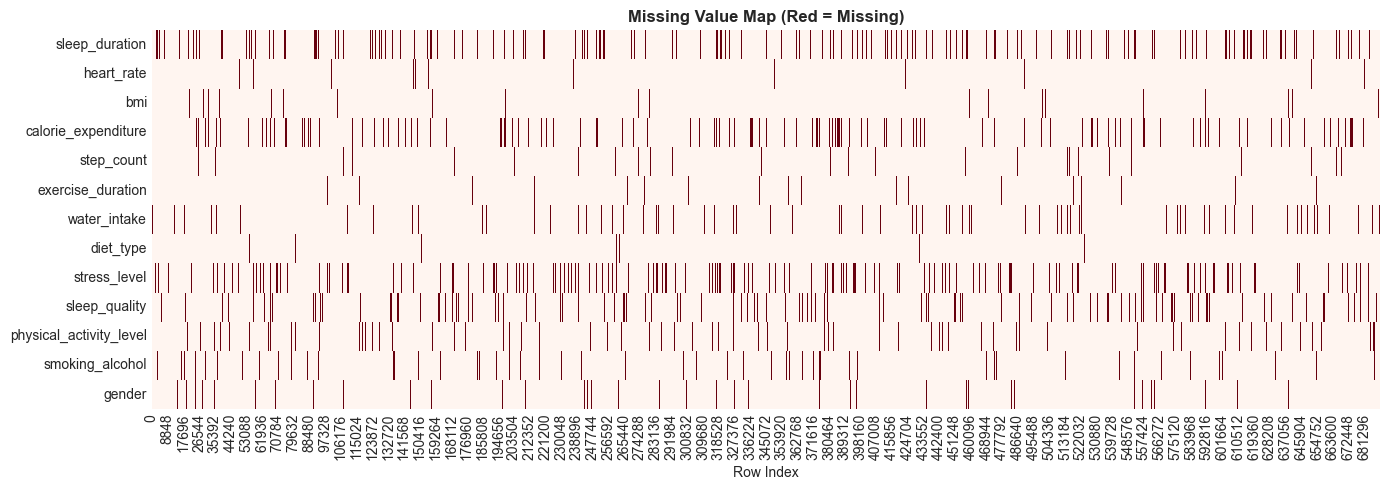

In [10]:
# ============================================================
# SECTION 8: Missing Value Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Create boolean mask: True = missing
missing_mask = train_df.isnull()

if missing_mask.any().any():
    # Show only columns with missing values
    missing_cols = missing_mask.columns[missing_mask.any()].tolist()
    sns.heatmap(
        missing_mask[missing_cols].T,
        cbar=False,
        cmap='Reds',
        yticklabels=True,
        ax=ax
    )
    ax.set_title('Missing Value Map (Red = Missing)', fontweight='bold')
    ax.set_xlabel('Row Index')
else:
    ax.text(0.5, 0.5, '✅ No Missing Values Found', ha='center', va='center',
            fontsize=16, transform=ax.transAxes)
    ax.set_title('Missing Value Map', fontweight='bold')

plt.tight_layout()
plt.savefig(PROC_DATA / 'eda_08_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. EDA Summary

Run this final cell to produce a written summary of EDA findings.

In [11]:
# ============================================================
# SECTION 9: EDA Phase Summary
# ============================================================

print('=' * 60)
print('  PHASE 3 COMPLETE — EDA Summary')
print('=' * 60)
print('  Charts produced:')
print('   ✅ Target distribution (bar + pie)')
print('   ✅ Numerical feature histograms')
print('   ✅ Box plots: features vs target')
print('   ✅ Categorical features vs target')
print('   ✅ Outlier detection (IQR method)')
print('   ✅ Correlation heatmap')
print('   ✅ Pairplot — feature interactions')
print('   ✅ Missing value heatmap')
print('=' * 60)
print('  Key Findings to Record in Report:')
print('   1. Target class balance/imbalance')
print('   2. Which numerical features separate classes best')
print('   3. Which categorical features show strong association')
print('   4. Features with high outlier rates')
print('   5. Highly correlated feature pairs')
print('=' * 60)
print('  ✅ Ready for Phase 4: Data Cleaning')
print('=' * 60)

  PHASE 3 COMPLETE — EDA Summary
  Charts produced:
   ✅ Target distribution (bar + pie)
   ✅ Numerical feature histograms
   ✅ Box plots: features vs target
   ✅ Categorical features vs target
   ✅ Outlier detection (IQR method)
   ✅ Correlation heatmap
   ✅ Pairplot — feature interactions
   ✅ Missing value heatmap
  Key Findings to Record in Report:
   1. Target class balance/imbalance
   2. Which numerical features separate classes best
   3. Which categorical features show strong association
   4. Features with high outlier rates
   5. Highly correlated feature pairs
  ✅ Ready for Phase 4: Data Cleaning
